
<div style="padding:28px 30px;border-radius:20px;background:linear-gradient(135deg,#07111f 0%,#0d1a33 45%,#1c2452 100%);color:#f2f6ff;border:1px solid rgba(160,190,255,0.25);box-shadow:0 18px 45px rgba(0,0,0,0.35);">
<h1 style="margin:0;font-size:2.2em;">S6E6 Cosmic EDA</h1>
<p style="margin:10px 0 0 0;font-size:1.05em;max-width:900px;line-height:1.6;">
A space-themed exploratory notebook for classifying astronomical objects into stars, galaxies, and quasars using sky position, photometric bands, redshift, and categorical descriptors.
</p>
</div>

<table style="width:100%;margin-top:16px;border-collapse:separate;border-spacing:12px;">
<tr>
<td style="width:33%;vertical-align:top;">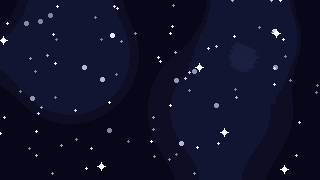</td>
<td style="width:33%;vertical-align:top;">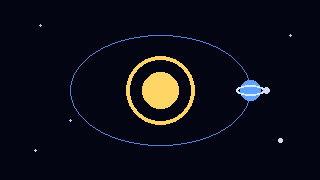</td>
<td style="width:33%;vertical-align:top;">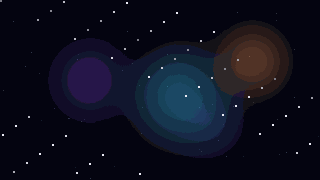</td>
</tr>
</table>



## Mission Brief
 Predict the stellar class. Yup thats all I have to say about the mission, the competition discription didn't give much information to put here xD pardon that and enjoy the space ride...


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='darkgrid', context='talk')
plt.rcParams.update({
    'figure.facecolor': '#08111f',
    'axes.facecolor': '#0b1526',
    'axes.edgecolor': '#9db4d3',
    'axes.labelcolor': '#edf4ff',
    'text.color': '#edf4ff',
    'xtick.color': '#dce8ff',
    'ytick.color': '#dce8ff',
    'grid.color': '#31405c',
    'grid.alpha': 0.28,
    'axes.titleweight': 'bold',
    'axes.titlepad': 12,
    'font.size': 11,
    'legend.frameon': True,
})

TARGET_ORDER = ['STAR', 'GALAXY', 'QSO']
TARGET_PALETTE = {
    'STAR': '#7ed0ff',
    'GALAXY': '#9f8cff',
    'QSO': '#ffc96b',
}
NUMERIC_COLUMNS = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

def cosmic_title(ax, title, subtitle=None):
    ax.set_title(title, loc='left', fontsize=16, pad=15)
    if subtitle:
        ax.text(0.0, 1.02, subtitle, transform=ax.transAxes, fontsize=10, color='#b8c7df', ha='left')


def tidy_legend(ax):
    legend = ax.legend(frameon=True, facecolor='#0b1526', edgecolor='#31405c')
    if legend:
        for text in legend.get_texts():
            text.set_color('#edf4ff')

print('Theme loaded. Ready for a deeper stellar scan.')


Theme loaded. Ready for a deeper stellar scan.



## Dataset Intake
The competition data lives in the Kaggle input folder. If you are running this locally, point `DATA_DIR` to the folder that holds `train.csv` and `test.csv`.


In [2]:
DATA_DIR_CANDIDATES = [
    Path('/kaggle/input/competitions/playground-series-s6e6'),
    Path('/kaggle/input/playground-series-s6e6'),
]

DATA_DIR = next((candidate for candidate in DATA_DIR_CANDIDATES if candidate.exists()), DATA_DIR_CANDIDATES[0])

train_df = pd.read_csv(DATA_DIR / 'train.csv')
test_df = pd.read_csv(DATA_DIR / 'test.csv')

print('train:', train_df.shape)
display(train_df.head())
print(
'test:', test_df.shape)
display(test_df.head())


train: (577347, 12)


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


test: (247435, 11)


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,577347,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,G/K,Red_Sequence
1,577348,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,M,Red_Sequence
2,577349,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,G/K,Blue_Cloud
3,577350,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,G/K,Red_Sequence
4,577351,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,M,Red_Sequence


In [3]:
overview = pd.DataFrame({
    'split': ['train', 'test'],
    'rows': [len(train_df), len(test_df)],
    'columns': [train_df.shape[1], test_df.shape[1]],
})

overview['memory_mb'] = [train_df.memory_usage(deep=True).sum() / 1024**2, test_df.memory_usage(deep=True).sum() / 1024**2]
display(overview.style.format({'memory_mb': '{:.2f}'}))

print('Columns:')
print(train_df.columns.tolist())


,split,rows,columns,memory_mb
0,train,577347,12,130.58
1,test,247435,11,43.20


Columns:
['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'class']



## Feature Atlas
- `alpha` and `delta` are sky coordinates that act like longitude and latitude on the celestial sphere.
- `u`, `g`, `r`, `i`, and `z` are photometric magnitudes from different filters; their differences often reveal class boundaries.
- `redshift` is the strongest physics-driven signal in this task and usually separates nearby stars from distant galaxies and quasars.
- `spectral_type` and `galaxy_population` are categorical descriptors that can reinforce or sharpen the numerical patterns.


In [4]:
feature_notes = pd.DataFrame({
    'feature': ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'class'],
    'type': ['numeric', 'numeric', 'numeric', 'numeric', 'numeric', 'numeric', 'numeric', 'numeric', 'categorical', 'categorical', 'target'],
    'role': [
        'sky position', 'sky position', 'photometric band', 'photometric band', 'photometric band', 'photometric band', 'photometric band',
        'distance proxy', 'metadata', 'metadata', 'label'
    ]
})
display(feature_notes)


,feature,type,role
0,alpha,numeric,sky position
1,delta,numeric,sky position
2,u,numeric,photometric band
3,g,numeric,photometric band
4,r,numeric,photometric band
5,i,numeric,photometric band
6,z,numeric,photometric band
7,redshift,numeric,distance proxy
8,spectral_type,categorical,metadata
9,galaxy_population,categorical,metadata



## Data Quality Check
Before getting lost in the nebula, we verify the basics: duplicates, missing values, and target balance.


Duplicate rows: 0


Series([], dtype: int64)

,count,share_percent
class,,
GALAXY,377480,65.38
QSO,117143,20.29
STAR,82724,14.33


/tmp/ipykernel_16/405329940.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='class', order=TARGET_ORDER, palette=TARGET_PALETTE, ax=ax)


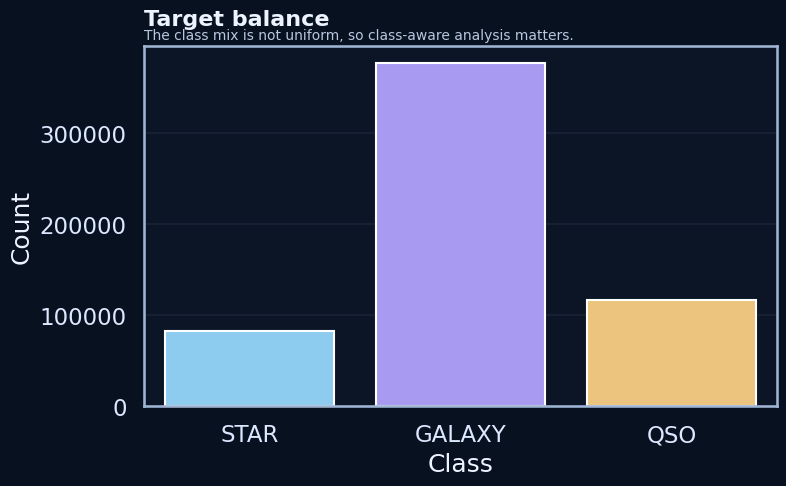

In [5]:
print('Duplicate rows:', train_df.duplicated().sum())

missing = train_df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
display(missing if not missing.empty else pd.Series(dtype='int64'))

class_counts = train_df['class'].value_counts()
class_share = train_df['class'].value_counts(normalize=True).mul(100).round(2)
summary_target = pd.DataFrame({'count': class_counts, 'share_percent': class_share})
display(summary_target)

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=train_df, x='class', order=TARGET_ORDER, palette=TARGET_PALETTE, ax=ax)
cosmic_title(ax, 'Target balance', 'The class mix is not uniform, so class-aware analysis matters.')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


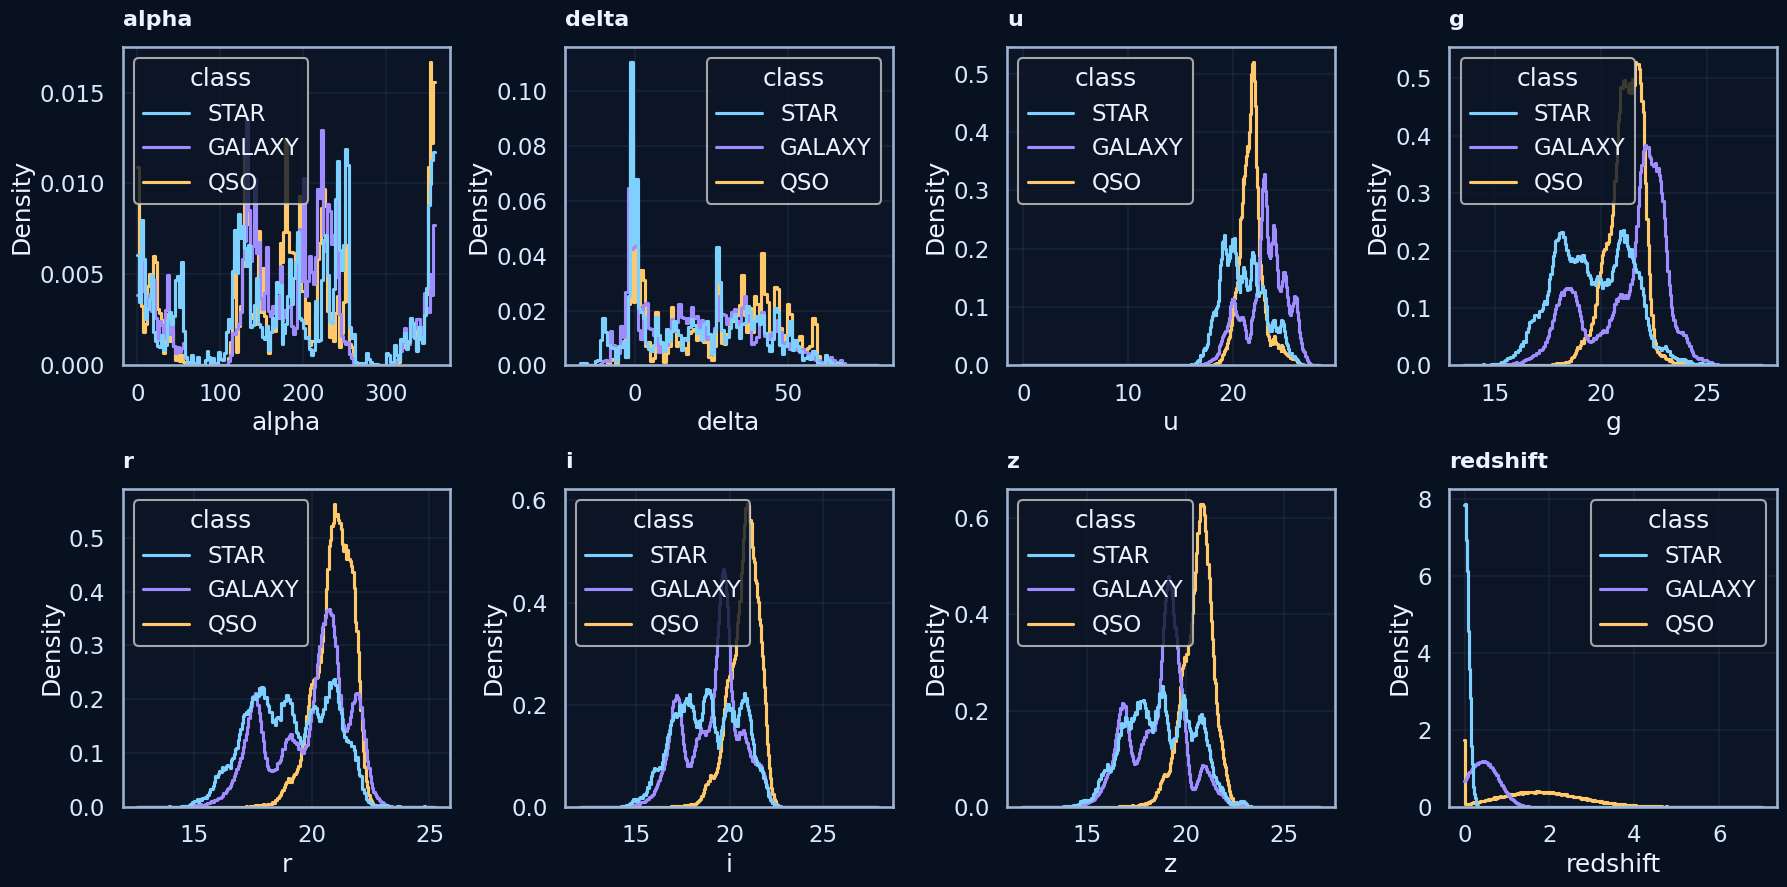

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for idx, col in enumerate(NUMERIC_COLUMNS):
    sns.histplot(
        data=train_df,
        x=col,
        hue='class',
        hue_order=TARGET_ORDER,
        element='step',
        stat='density',
        common_norm=False,
        fill=False,
        palette=TARGET_PALETTE,
        ax=axes[idx],
    )
    cosmic_title(axes[idx], col)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Density')

plt.tight_layout()
plt.show()


/tmp/ipykernel_16/137082492.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_16/137082492.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_16/137082492.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_16/137082492.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_16/137082492.py:5: FutureWarning: 

Passing `

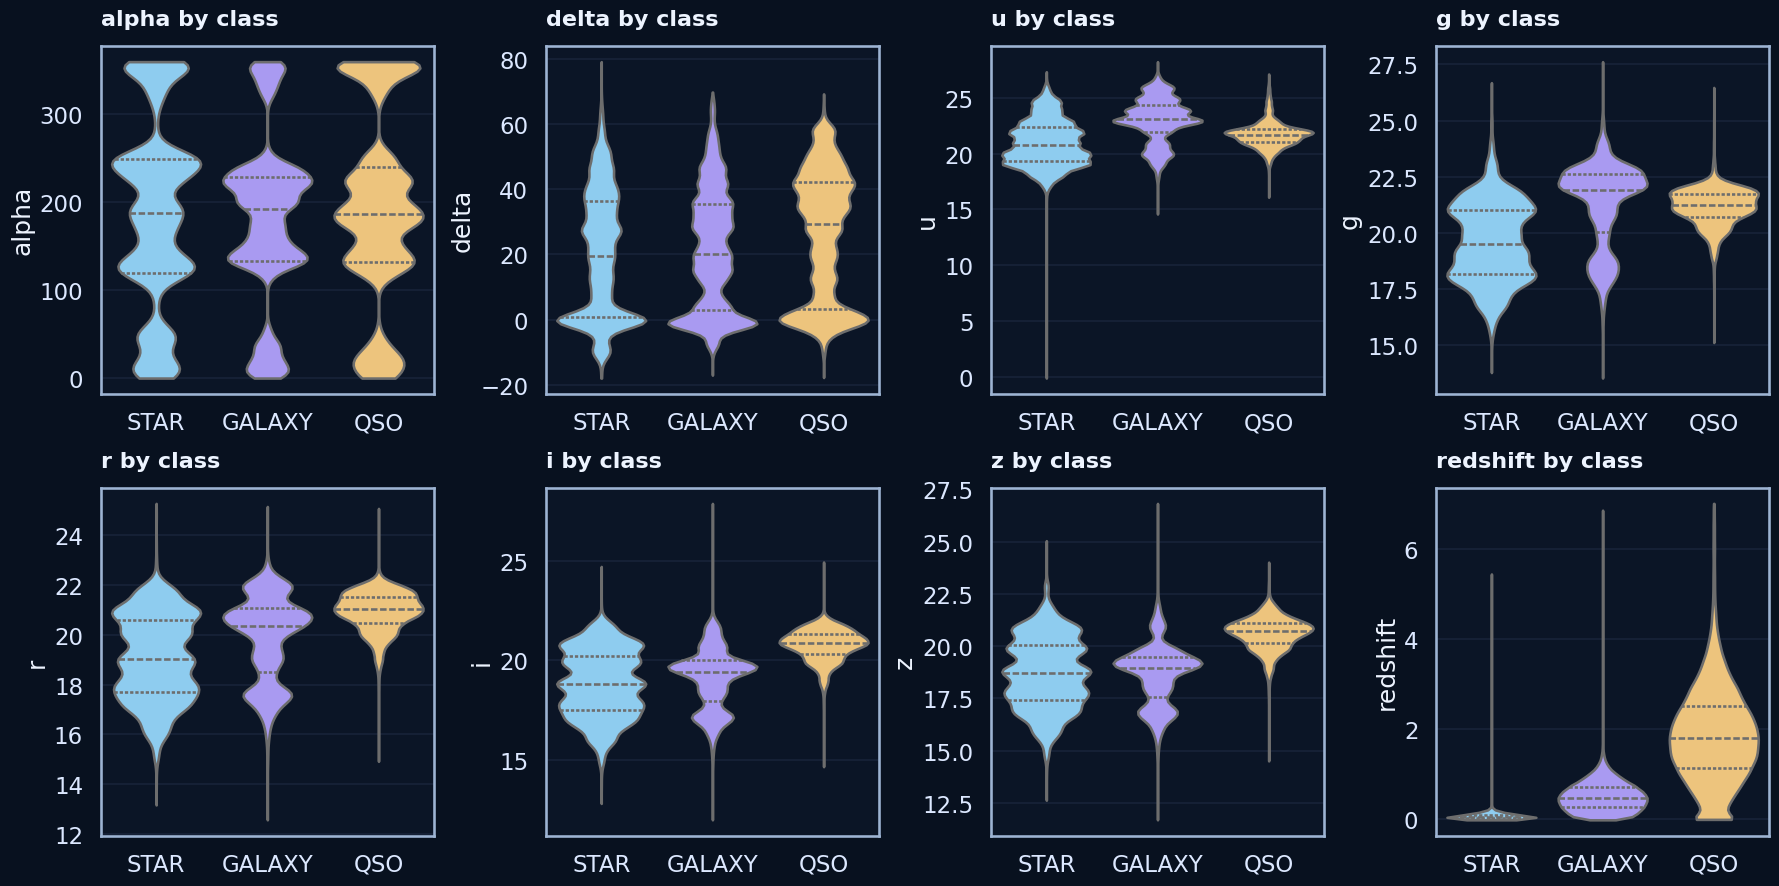

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for idx, col in enumerate(NUMERIC_COLUMNS):
    sns.violinplot(
        data=train_df,
        x='class',
        y=col,
        order=TARGET_ORDER,
        palette=TARGET_PALETTE,
        inner='quartile',
        cut=0,
        ax=axes[idx],
    )
    cosmic_title(axes[idx], f'{col} by class')
    axes[idx].set_xlabel('')

plt.tight_layout()
plt.show()


* The dataset is large: 577,347 train rows and 247,435 test rows.
* Data quality looks clean: 0 duplicates and no missing values shown in the notebook.
* The target is imbalanced: GALAXY 65.38%, QSO 20.29%, STAR 14.33%.


## Numerical Signal
The aim here is not just to see shape, but to find which measurements show the strongest class separation and whether any filter bands move together in a predictable way.


In [8]:
class_summary = train_df.groupby('class')[NUMERIC_COLUMNS].agg(['mean', 'median', 'std', 'min', 'max']).round(3)
display(class_summary)


alpha                                   delta                                       u                                      g  \
           mean   median      std    min    max    mean  median     std     min     max    mean  median    std     min     max    mean   
class                                                                                                                                    
GALAXY  178.557  191.988   91.831  0.023  360.0  21.033  20.015  18.481 -17.082  69.824  22.989  23.139  1.997  14.578  28.253  21.270   
QSO     189.666  186.152  103.471  0.012  360.0  25.812  29.279  19.583 -17.799  69.263  21.725  21.701  1.151  16.084  27.145  21.160   
STAR    184.179  188.069  104.231  0.023  360.0  19.859  19.567  19.264 -17.967  79.158  20.960  20.758  2.017  -0.139  27.349  19.591   

                                            r                                      i                                      z          \
        median    std     min     max    mean  median    std     min     max    mean  median    std     min     max    mean  median   
class                                                                                                                                 
GALAXY  21.917  1.876  13.535  27.620  19.861  20.330  1.690  12.579  25.132  19.068  19.399  1.500  11.963  27.911  18.630  18.928   
QSO     21.246  0.825  15.119  26.473  20.919  21.013  0.795  14.922  25.055  20.767  20.869  0.792  14.641  24.956  20.602  20.698   
STAR    19.507  1.767  13.781  26.685  19.076  19.034  1.709  13.176  25.254  18.831  18.816  1.674  12.788  24.733  18.707  18.696   

                              redshift                             
          std     min     max     mean median    std   min    max  
class                                                              
GALAXY  1.443  11.683  26.827    0.509  0.482  0.309 -0.01  6.860  
QSO     0.787  14.502  24.015    1.876  1.799  1.070  0.00  7.011  
STAR    1.677  12.621  25.043    0.068  0.056  0.064 -0.01  5.445

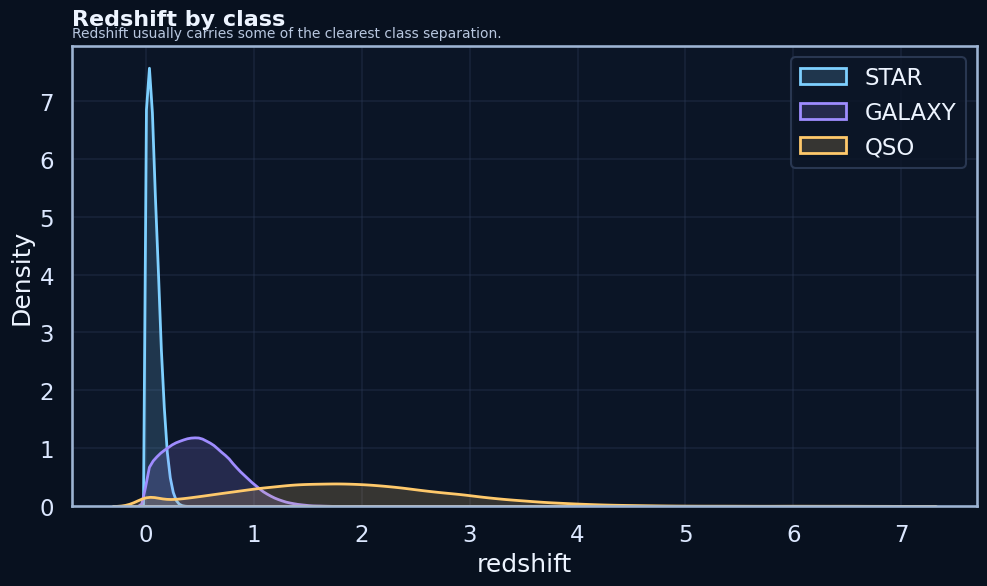

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
for cls in TARGET_ORDER:
    subset = train_df.loc[train_df['class'] == cls, 'redshift']
    sns.kdeplot(subset, label=cls, fill=True, alpha=0.18, linewidth=2, ax=ax, color=TARGET_PALETTE[cls])
cosmic_title(ax, 'Redshift by class', 'Redshift usually carries some of the clearest class separation.')
ax.set_xlabel('redshift')
ax.set_ylabel('Density')
tidy_legend(ax)
plt.tight_layout()
plt.show()


/tmp/ipykernel_16/1785461191.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='class', y='redshift', order=TARGET_ORDER, palette=TARGET_PALETTE, ax=ax)


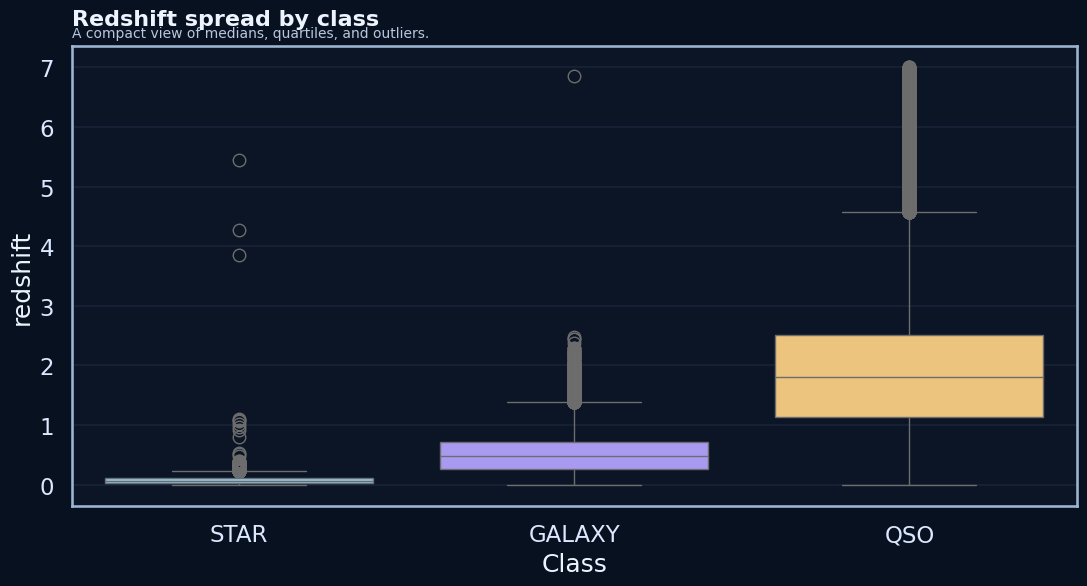

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=train_df, x='class', y='redshift', order=TARGET_ORDER, palette=TARGET_PALETTE, ax=ax)
cosmic_title(ax, 'Redshift spread by class', 'A compact view of medians, quartiles, and outliers.')
ax.set_xlabel('Class')
ax.set_ylabel('redshift')
plt.tight_layout()
plt.show()


**redshift** is the clearest separator.

From the class summary:
* STAR has very low redshift on average (~0.068)
* GALAXY is higher (~0.509)
* QSO is highest (~1.876)
* The redshift density and boxplot show strong separation, especially for QSO versus STAR.

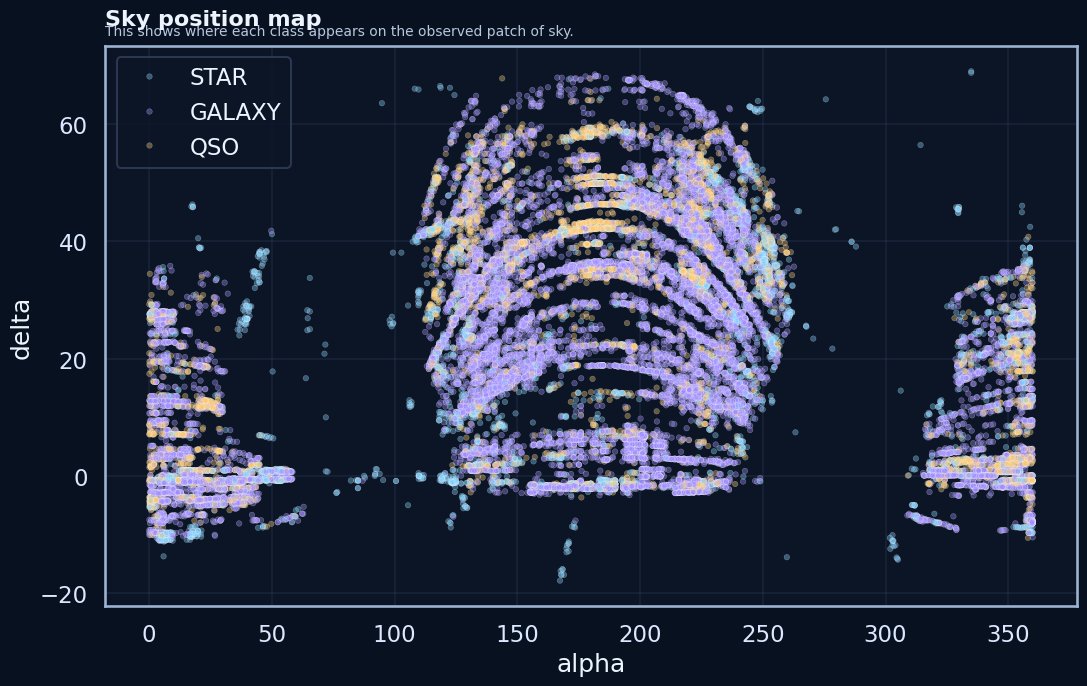

In [11]:
fig, ax = plt.subplots(figsize=(11, 7))
sky_sample = train_df.sample(n=min(len(train_df), 30000), random_state=42)
sns.scatterplot(
    data=sky_sample,
    x='alpha',
    y='delta',
    hue='class',
    hue_order=TARGET_ORDER,
    palette=TARGET_PALETTE,
    alpha=0.38,
    s=16,
    ax=ax,
)
cosmic_title(ax, 'Sky position map', 'This shows where each class appears on the observed patch of sky.')
ax.set_xlabel('alpha')
ax.set_ylabel('delta')
tidy_legend(ax)
plt.tight_layout()
plt.show()


alpha and delta wont be of much use as expected, the smaples seem to be scattered across the space, still it wont hurt to explore spatial features ig.

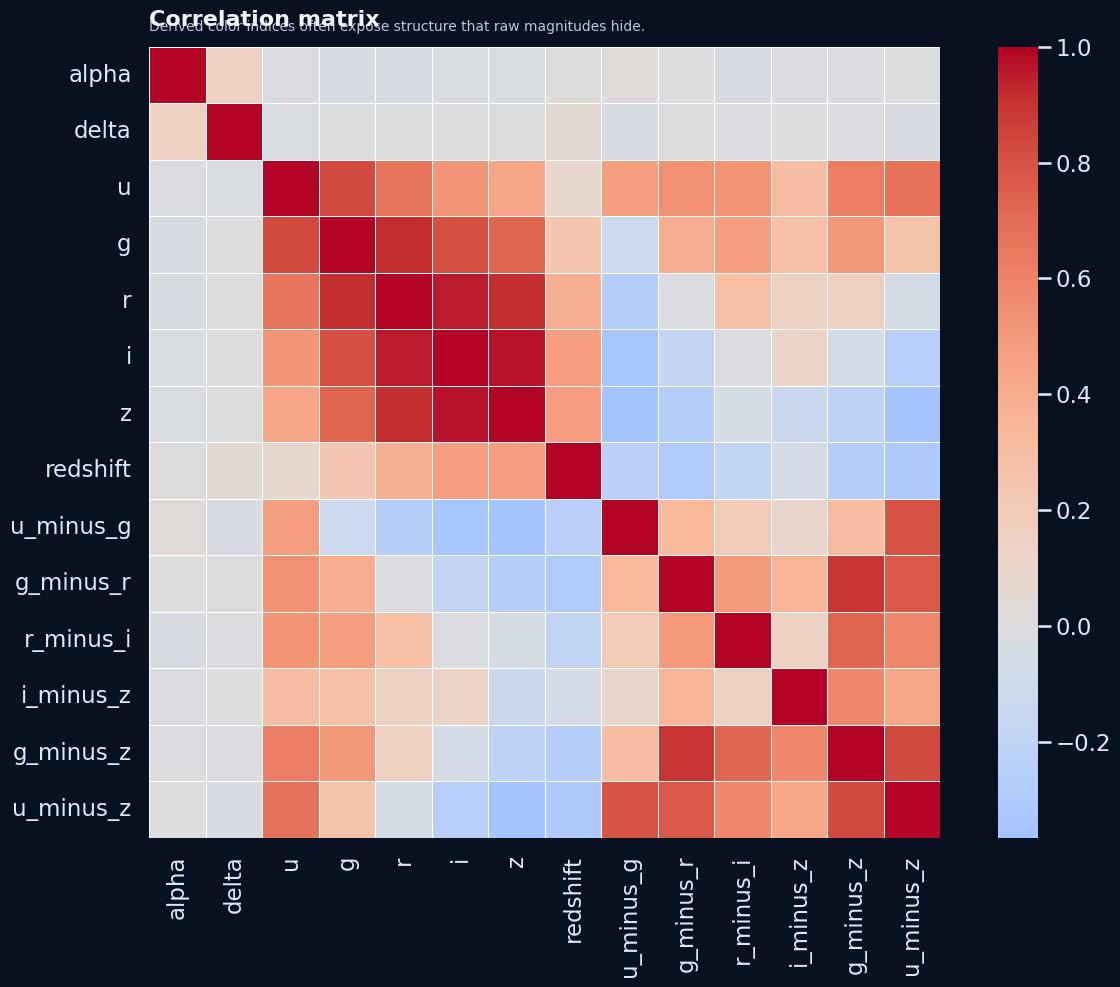

In [12]:
derived = train_df.copy()
derived['u_minus_g'] = derived['u'] - derived['g']
derived['g_minus_r'] = derived['g'] - derived['r']
derived['r_minus_i'] = derived['r'] - derived['i']
derived['i_minus_z'] = derived['i'] - derived['z']
derived['g_minus_z'] = derived['g'] - derived['z']
derived['u_minus_z'] = derived['u'] - derived['z']

derived_features = ['u_minus_g', 'g_minus_r', 'r_minus_i', 'i_minus_z', 'g_minus_z', 'u_minus_z']

corr = derived[NUMERIC_COLUMNS + derived_features].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, linewidths=0.4, ax=ax)
cosmic_title(ax, 'Correlation matrix', 'Derived color indices often expose structure that raw magnitudes hide.')
plt.tight_layout()
plt.show()


/tmp/ipykernel_16/1668548823.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=derived, x='class', y=col, order=TARGET_ORDER, palette=TARGET_PALETTE, ax=axes[idx])
/tmp/ipykernel_16/1668548823.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=derived, x='class', y=col, order=TARGET_ORDER, palette=TARGET_PALETTE, ax=axes[idx])
/tmp/ipykernel_16/1668548823.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=derived, x='class', y=col, order=TARGET_ORDER, palette=TARGET_PALETTE, ax=axes[idx])
/tmp/ipykernel_16/1668548823.py:5:

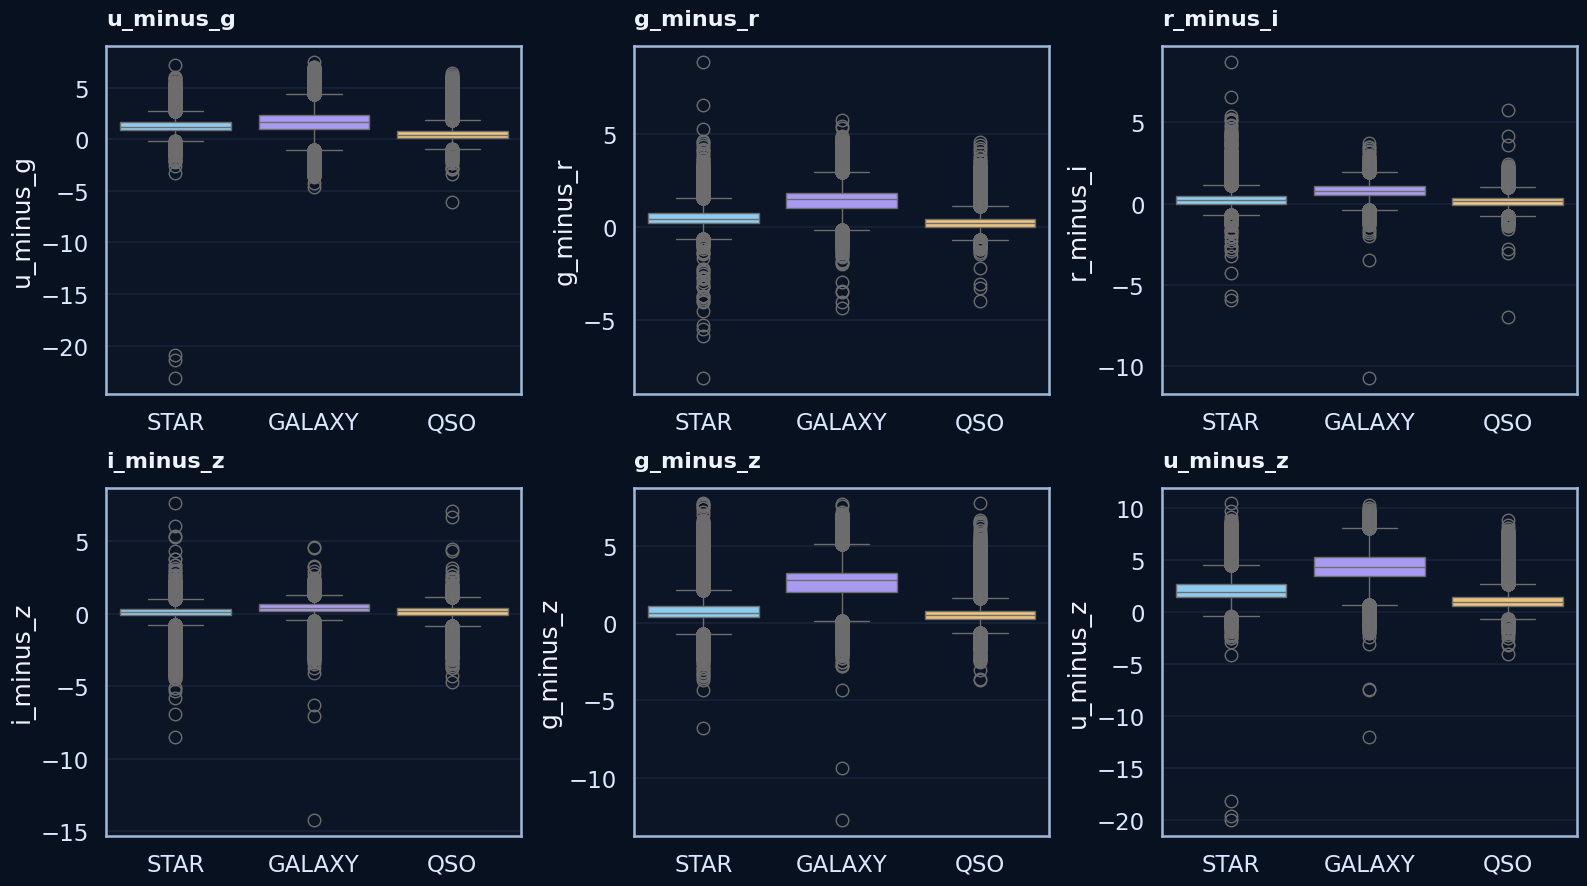

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, col in enumerate(derived_features):
    sns.boxplot(data=derived, x='class', y=col, order=TARGET_ORDER, palette=TARGET_PALETTE, ax=axes[idx])
    cosmic_title(axes[idx], col)
    axes[idx].set_xlabel('')

plt.tight_layout()
plt.show()


* The raw bands (u, g, r, i, z) are informative, but they separate classes best when compared as differences.
* The correlation heatmap shows the bands are strongly related to each other, which is expected in astronomy.
* The derived color indices (u-g, g-r, r-i, i-z, etc.) make the class structure clearer than the raw magnitudes alone.


## Categorical Layers
The categorical fields are not the star of the show, but they can still reveal useful texture once we look at them class by class.


/tmp/ipykernel_16/480244940.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df.assign(temp=temp), x='temp', order=order, palette='viridis', ax=ax)
/tmp/ipykernel_16/480244940.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df.assign(temp=temp), x='temp', order=order, palette='viridis', ax=ax)


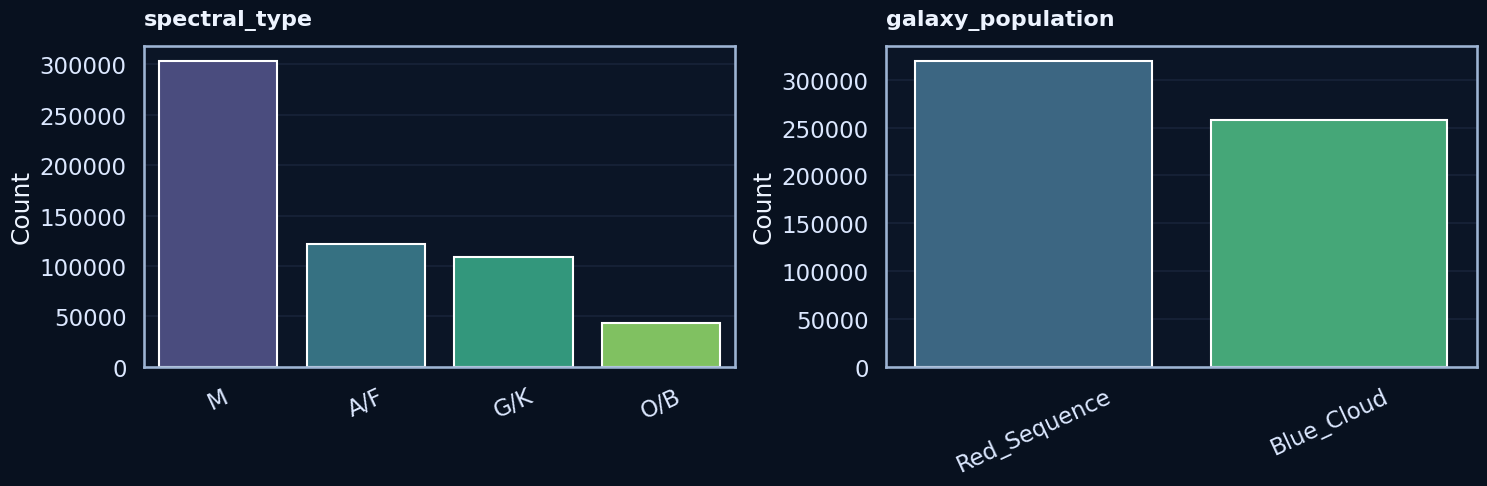

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, col in zip(axes, ['spectral_type', 'galaxy_population']):
    temp = train_df[col].fillna('Missing').astype(str)
    order = temp.value_counts().index.tolist()
    sns.countplot(data=train_df.assign(temp=temp), x='temp', order=order, palette='viridis', ax=ax)
    cosmic_title(ax, col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


class,STAR,GALAXY,QSO
spectral_type,,,
A/F,0.298,0.198,0.504
G/K,0.240,0.568,0.193
M,0.038,0.950,0.013
O/B,0.206,0.083,0.711


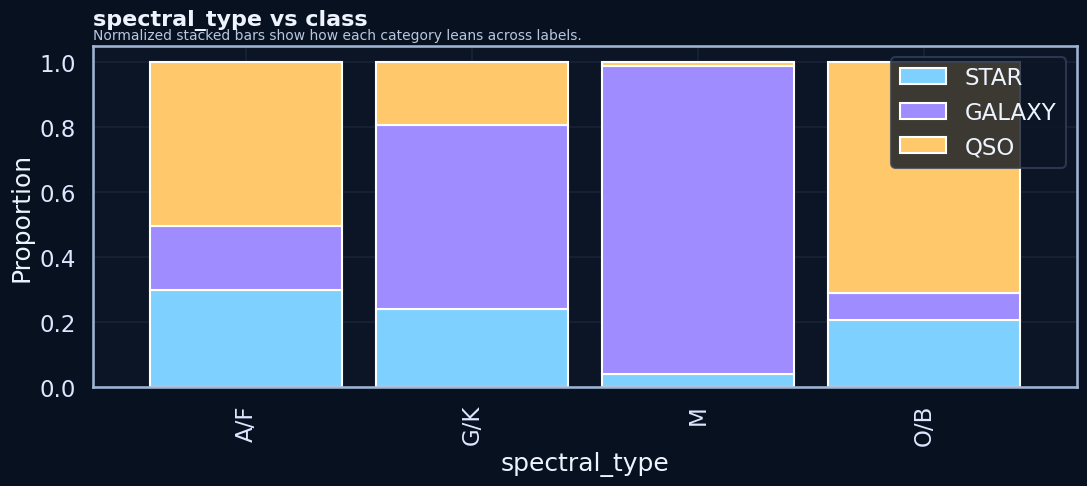

class,STAR,GALAXY,QSO
galaxy_population,,,
Blue_Cloud,0.235,0.345,0.420
Red_Sequence,0.069,0.903,0.028


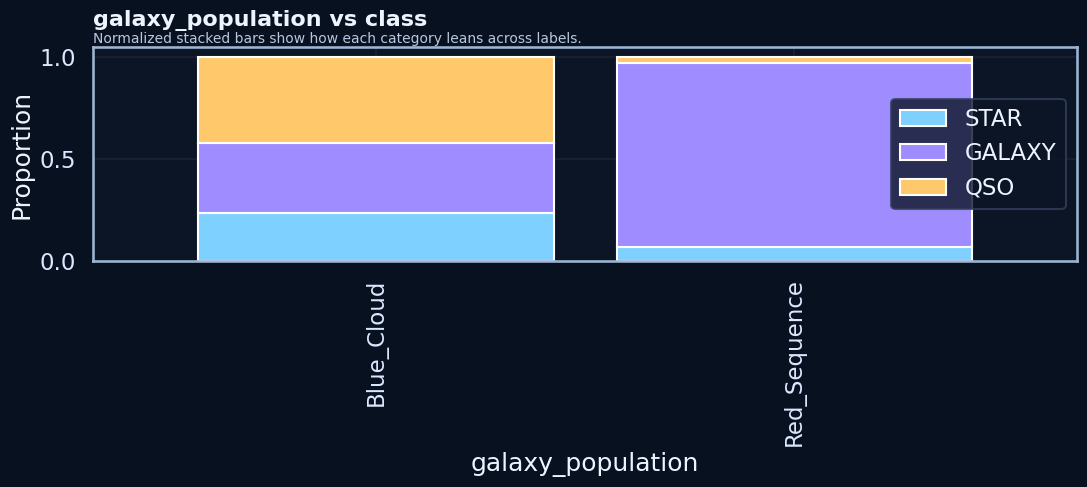

In [15]:
for col in ['spectral_type', 'galaxy_population']:
    ct = pd.crosstab(train_df[col], train_df['class'], normalize='index').reindex(columns=TARGET_ORDER)
    display(ct.round(3))

    fig, ax = plt.subplots(figsize=(11, 5))
    ct.plot(kind='bar', stacked=True, ax=ax, color=[TARGET_PALETTE[c] for c in TARGET_ORDER], width=0.85)
    cosmic_title(ax, f'{col} vs class', 'Normalized stacked bars show how each category leans across labels.')
    ax.set_xlabel(col)
    ax.set_ylabel('Proportion')
    ax.legend(title='class')
    tidy_legend(ax)
    plt.tight_layout()
    plt.show()


**spectral_type** is very useful:
   * M is overwhelmingly GALAXY (95.0%)
   * O/B is mostly QSO (71.1%)
   * G/K leans GALAXY (56.8%)
   * A/F is mixed, but leans QSO (50.4%)

**galaxy_population** also helps:
   * Red_Sequence is strongly GALAXY (90.3%)
   * Blue_Cloud is more mixed, with QSO the largest share (42.0%)


## Class Separation Check
A fast projection like PCA is useful for a first pass because it compresses the signal and shows whether the classes naturally cluster.


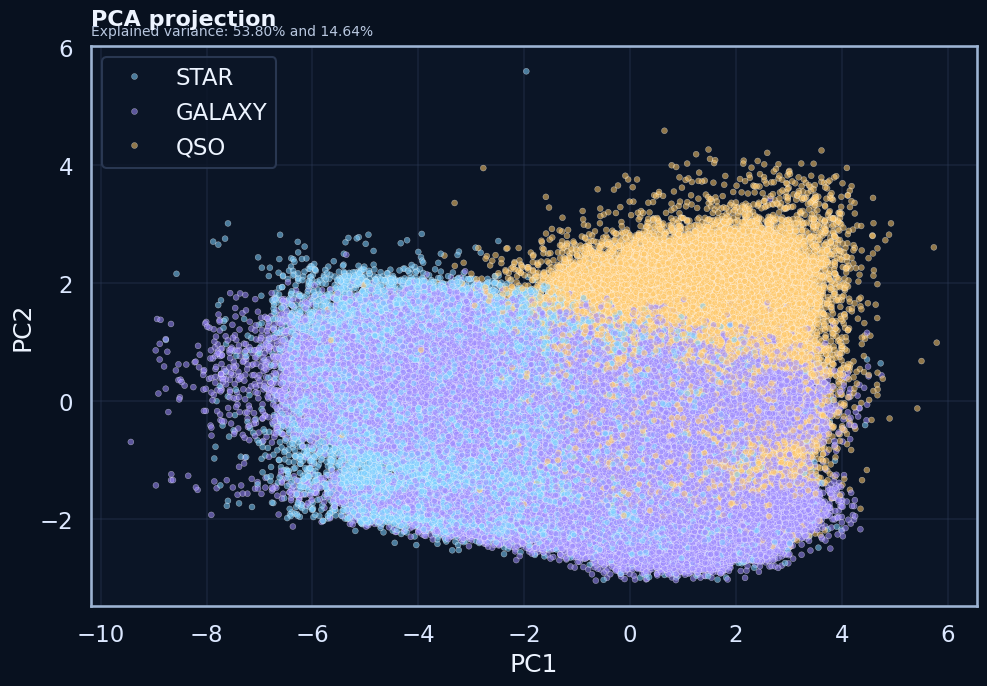

In [16]:
projection_columns = NUMERIC_COLUMNS.copy()
scaled = StandardScaler().fit_transform(train_df[projection_columns])
pca = PCA(n_components=2, random_state=42)
projection = pca.fit_transform(scaled)
projection_df = pd.DataFrame(projection, columns=['PC1', 'PC2'])
projection_df['class'] = train_df['class'].values

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=projection_df,
    x='PC1',
    y='PC2',
    hue='class',
    hue_order=TARGET_ORDER,
    palette=TARGET_PALETTE,
    alpha=0.55,
    s=18,
    ax=ax,
)
cosmic_title(ax, 'PCA projection', f'Explained variance: {pca.explained_variance_ratio_[0]:.2%} and {pca.explained_variance_ratio_[1]:.2%}')
tidy_legend(ax)
plt.tight_layout()
plt.show()


* The PCA plot shows partial class structure, not perfect separation.
* The reports explained variance of about 53.80% for PC1 and 14.64% for PC2.
* QSO tends to sit more distinctly on the positive side of the projection, while STAR and GALAXY overlap more.


## Takeaway Notes
- `redshift` is the most obvious class-separating feature to inspect first.
- The photometric bands gain a lot of meaning once you look at their differences rather than only their raw values.
- `alpha` and `delta` tell you where the sample sits on the sky, but they are usually more supportive than decisive.
- The categorical descriptors are worth keeping, especially if they add consistency around the numerical patterns.

Next step, a baseline classifier comparison.

## Baseline:
This section turns the EDA into a first model. We keep the strongest engineered signals, encode the categorical columns, and compare a simple linear baseline with a tree-based baseline before training the best one on the full dataset.

,model,balanced_accuracy,macro_f1
2,hist_gradient_boosting,0.9506,0.9519
1,logistic_regression,0.8943,0.8980
0,dummy,0.3333,0.2636


Best validation model: hist_gradient_boosting
              precision    recall  f1-score   support

        STAR       0.92      0.91      0.92     12409
      GALAXY       0.97      0.98      0.98     56622
         QSO       0.96      0.96      0.96     17572

    accuracy                           0.96     86603
   macro avg       0.95      0.95      0.95     86603
weighted avg       0.96      0.96      0.96     86603



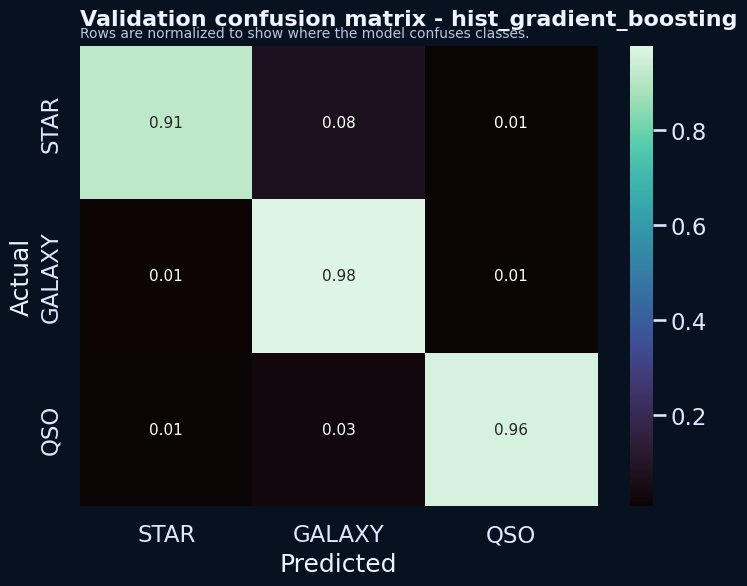

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse=False)

#engineered features
def add_color_features(frame):
    frame = frame.copy()
    frame['u_minus_g'] = frame['u'] - frame['g']
    frame['g_minus_r'] = frame['g'] - frame['r']
    frame['r_minus_i'] = frame['r'] - frame['i']
    frame['i_minus_z'] = frame['i'] - frame['z']
    frame['g_minus_z'] = frame['g'] - frame['z']
    frame['u_minus_z'] = frame['u'] - frame['z']
    return frame

train_model_df = add_color_features(train_df)
test_model_df = add_color_features(test_df)

feature_columns = [column for column in train_model_df.columns if column not in ['id', 'class']]
target = train_model_df['class']
numeric_features = [column for column in feature_columns if train_model_df[column].dtype != 'object']
categorical_features = [column for column in feature_columns if train_model_df[column].dtype == 'object']

#splitting data
X_train, X_valid, y_train, y_valid = train_test_split(
    train_model_df[feature_columns],
    target,
    test_size=0.15,
    random_state=42,
    stratify=target,
)

#preprocessing pipelines
numeric_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
numeric_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', one_hot),
])

preprocess_lr = ColumnTransformer([
    ('num', numeric_lr, numeric_features),
    ('cat', categorical_pipe, categorical_features),
])
preprocess_tree = ColumnTransformer([
    ('num', numeric_tree, numeric_features),
    ('cat', categorical_pipe, categorical_features),
])

#models
models = {
    'dummy': Pipeline([
        ('preprocess', preprocess_tree),
        ('model', DummyClassifier(strategy='most_frequent')),
    ]),
    'logistic_regression': Pipeline([
        ('preprocess', preprocess_lr),
        ('model', LogisticRegression(max_iter=1200, n_jobs=-1, solver='saga')),
    ]),
    'hist_gradient_boosting': Pipeline([
        ('preprocess', preprocess_tree),
        ('model', HistGradientBoostingClassifier(
            learning_rate=0.08,
            max_iter=220,
            max_depth=8,
            random_state=42,
        )),
    ]),
}

#training and result comparison
results = []
fitted_models = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline
    validation_pred = pipeline.predict(X_valid)
    results.append({
        'model': name,
        'balanced_accuracy': balanced_accuracy_score(y_valid, validation_pred),
        'macro_f1': f1_score(y_valid, validation_pred, average='macro'),
    })

results_df = pd.DataFrame(results).sort_values(['balanced_accuracy', 'macro_f1'], ascending=False)
display(results_df.style.format({'balanced_accuracy': '{:.4f}', 'macro_f1': '{:.4f}'}))

best_model_name = results_df.iloc[0]['model']
best_model = fitted_models[best_model_name]
best_validation_pred = best_model.predict(X_valid)

print('Best validation model:', best_model_name)
print(classification_report(y_valid, best_validation_pred, labels=TARGET_ORDER, zero_division=0))

cm = confusion_matrix(y_valid, best_validation_pred, labels=TARGET_ORDER, normalize='true')
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='mako', xticklabels=TARGET_ORDER, yticklabels=TARGET_ORDER, ax=ax)
cosmic_title(ax, f'Validation confusion matrix - {best_model_name}', 'Rows are normalized to show where the model confuses classes.')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


In [18]:
# Refitting the best baseline on the full training set and creating a submission file.
final_model = models[best_model_name]
final_model.fit(train_model_df[feature_columns], target)

test_predictions = final_model.predict(test_model_df[feature_columns])
submission = pd.DataFrame({
    'id': test_model_df['id'],
    'class': test_predictions,
})

display(submission.head())
display(submission['class'].value_counts())
submission.to_csv('submission.csv', index=False)
print('Saved submission.csv')

,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY


class
GALAXY    162085
QSO        50029
STAR       35321
Name: count, dtype: int64

Saved submission.csv


<div align='center'> Thanks for reading till the end, hope it helped!! Feedback is always appretiated!! </div>